- Linear / Regularized Linear Models
- Ridge
- Lasso
- LassoCV
- RidgeCV
- ElasticNetCV
- BayesianRidge
- HuberRegressor
- SGDRegressor
- PassiveAggressiveRegressor
- QuantileRegressor
- PoissonRegressor
- GammaRegressor
- TweedieRegressor
- OrthogonalMatchingPursuit


- Tree-Based Models
- DecisionTreeRegressor
- RandomForestRegressor
- ExtraTreesRegressor
- GradientBoostingRegressor
- HistGradientBoostingRegressor
- AdaBoostRegressor
- BaggingRegressor


- Advanced Boosting Libraries
- XGBRegressor from XGBoost
- LGBMRegressor from LightGBM
- CatBoostRegressor from CatBoost


- Kernel / Margin-Based Models
- SVR
- NuSVR
- KernelRidge


- KNeighborsRegressor
- RadiusNeighborsRegressor


- MLPRegressor



You could also wrap deep learning models manually if they expose fit() and predict().

- Probabilistic / Bayesian Models
- GaussianProcessRegressor
- BayesianRidge
- ARDRegression


- RANSACRegressor
- TheilSenRegressor
- HuberRegressor



- Ensemble Meta-Models
- VotingRegressor
- StackingRegressor

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

!pip install merf
!pip install sklearn.metrics
from sklearn.metrics import mean_squared_error
from scipy.stats import wilcoxon

from merf.merf import MERF

# -----------------------------
# Paths
# -----------------------------
dataset = Path("C:/Users/janku/Documents/KCL/Research Project/Research Project/data/processed/radar_model_dataset_raw_features.csv")

RESULTS_PATH = Path(
    "C:/Users/janku/Documents/KCL/Research Project/Research Project/results/metrics/SVM/MERF/RADAR"
)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(dataset)

# -----------------------------
# Clean data
# -----------------------------
df["recording_date"] = pd.to_datetime(df["recording_date"], errors="coerce")
df["participant_id"] = df["participant_id"].astype(str).str.strip()

# -----------------------------
# Outcome + grouping
# -----------------------------
y_score = df["phq8_score"]
ID_clusters = df["participant_id"]

# -----------------------------
# Random-effect covariates (Z)
# -----------------------------
z_candidates = [
    "Age",
    "Gender",
    "Education_Years",
    "Height"
]

z_features = [c for c in z_candidates if c in df.columns]
Z_factors = df[z_features].copy()

# -----------------------------
# Fixed-effect speech features (X)
# -----------------------------
x_candidates = [
    "Speaking_Rate",
    "Articulation_Rate",
    "Phonation_Ratio",
    "Pause_Rate",
    "Pause_Ratio",
    "mean_F0",
    "stdev_F0_Semitone",
    "HNR_dB",
    "Spectral_Slope",
    "Spectral_Tilt",
    "Cepstral_Peak_Prominence",
    "mean_F1_Loc",
    "std_F1_Loc",
    "mean_B1_Loc",
    "std_B1_Loc",
    "mean_F2_Loc",
    "std_F2_Loc",
    "mean_B2_Loc",
    "std_B2_Loc",
    "Spectral_Gravity",
    "Spectral_Std_Dev"
]

feature_cols = [c for c in x_candidates if c in df.columns]

# -----------------------------
# Remove missing values
# -----------------------------
required_cols = feature_cols + z_features + ["phq8_score", "participant_id"]

df_clean = df.dropna(subset=required_cols).copy()

X = df_clean[feature_cols]
Z_factors = df_clean[z_features]
y_score = df_clean["phq8_score"]
ID_clusters = df_clean["participant_id"]

print("Rows:", len(df_clean))
print("Participants:", df_clean["participant_id"].nunique())
print("Features used:", feature_cols)
print("Random-effect covariates:", z_features)

# -----------------------------
# GroupKFold CV + simple GridSearchCV for SVR
# -----------------------------
gkf = GroupKFold(n_splits=5)

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

param_grid = {
    "svr__kernel": ["rbf"],
    "svr__C": [1.0, 10.0],
    "svr__epsilon": [0.1, 0.2],
    "svr__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=gkf,
    n_jobs=-1
)
grid.fit(X, y_score, groups=ID_clusters)

best_svr_params = {
    k.replace("svr__", ""): v
    for k, v in grid.best_params_.items()
    if k.startswith("svr__")
}
print("Best SVR params from GridSearchCV:", best_svr_params)

rmse_list = []
fold_results = []

for fold, (train_index, test_index) in enumerate(
    gkf.split(X, y_score, groups=ID_clusters), start=1
):
    print(f"\nProcessing fold {fold}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_score.iloc[train_index], y_score.iloc[test_index]

    clusters_train = ID_clusters.iloc[train_index]
    clusters_test = ID_clusters.iloc[test_index]

    Z_train = Z_factors.iloc[train_index]
    Z_test = Z_factors.iloc[test_index]

    # Scale X only
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # MERF model
    rf_reg = SVR(**best_svr_params)

    merf_model = MERF(
        fixed_effects_model=rf_reg,
        max_iterations=20
    )

    merf_model.fit(
        X_train_scaled,
        Z_train,
        clusters_train,
        y_train
    )

    y_pred = merf_model.predict(
        X_test_scaled,
        Z_test,
        clusters_test
    )

    mse = mean_squared_error(
        y_test,
        y_pred,
    )
    rmse = np.sqrt(mse)
    rmse_list.append(rmse)

    # Paired Wilcoxon: |y - ŷ_MERF| vs |y - ȳ_train| (per-sample; tests whether MERF fits better than mean baseline)
    baseline = np.full_like(y_test, fill_value=np.mean(y_train), dtype=float)
    e_merf = np.abs(np.asarray(y_test) - np.asarray(y_pred))
    e_mean = np.abs(np.asarray(y_test) - baseline)
    if len(e_merf) >= 2 and not np.allclose(e_merf, e_mean):
        w_res = wilcoxon(e_merf, e_mean, zero_method="wilcox", mode="auto")
        wilcoxon_p = float(w_res.pvalue)
    else:
        wilcoxon_p = float("nan")
    print(f"  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold {fold}:", wilcoxon_p)
    if wilcoxon_p < 0.05:
        print("    MERF abs errors differ from mean baseline (alpha=0.05).")
    else:
        print("    No significant difference from mean baseline at alpha=0.05 (improvement may be chance on this split).")

    fold_results.append({
        "fold": fold,
        "n_train": len(train_index),
        "n_test": len(test_index),
        "rmse": rmse,
        "wilcoxon_p_vs_train_mean_baseline": wilcoxon_p
    })

    print(f"Fold RMSE = {rmse:.2f}")

# -----------------------------
# Summary
# -----------------------------
fold_results_df = pd.DataFrame(fold_results)

summary_df = pd.DataFrame([{
    "subset": "all",
    "n_rows": len(df_clean),
    "n_participants": df_clean["participant_id"].nunique(),
    "rmse_mean": np.mean(rmse_list),
    "rmse_std": np.std(rmse_list)
}])

print("\nFold results:")
print(fold_results_df)

print("\nSummary:")
print(summary_df)

# -----------------------------
# Save results
# -----------------------------
fold_results_df.to_csv(
    RESULTS_PATH / "radar_merf_svr_cv_folds.csv",
    index=False
)

summary_df.to_csv(
    RESULTS_PATH / "radar_merf_svr_summary.csv",
    index=False
)

print("\nResults saved to:")
print(RESULTS_PATH)


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement sklearn.metrics (from versions: none)
ERROR: No matching distribution found for sklearn.metrics

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Rows: 8515
Participants: 274
Features used: ['Speaking_Rate', 'Articulation_Rate', 'Phonation_Ratio', 'Pause_Rate', 'Pause_Ratio', 'mean_F0', 'stdev_F0_Semitone', 'HNR_dB', 'Spectral_Slope', 'Spectral_Tilt', 'Cepstral_Peak_Prominence', 'mean_F1_Loc', 'std_F1_Loc', 'mean_B1_Loc', 'std_B1_Loc', 'mean_F2_Loc', 'std_F2_Loc', 'mean_B2_Loc', 'std_B2_Loc', 'Spectral_Gravity', 'Spectral_Std_Dev']
Random-effect covariates: ['Age', 'Gender', 'Education_Years', 'Height']
Best SVR params from GridSearchCV: {'C': 1.0, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}

Processing fold 1


INFO     [merf.py:307] Training GLL is 22465.192076892636 at iteration 1.
INFO     [merf.py:307] Training GLL is 21138.296396983817 at iteration 2.
INFO     [merf.py:307] Training GLL is 20752.198151623903 at iteration 3.
INFO     [merf.py:307] Training GLL is 20515.063275619214 at iteration 4.
INFO     [merf.py:307] Training GLL is 20350.608962726066 at iteration 5.
INFO     [merf.py:307] Training GLL is 20232.080495965747 at iteration 6.
INFO     [merf.py:307] Training GLL is 20146.644267126896 at iteration 7.
INFO     [merf.py:307] Training GLL is 20087.467784288958 at iteration 8.
INFO     [merf.py:307] Training GLL is 20047.634197373205 at iteration 9.
INFO     [merf.py:307] Training GLL is 20019.99852289036 at iteration 10.
INFO     [merf.py:307] Training GLL is 20000.53749316919 at iteration 11.
INFO     [merf.py:307] Training GLL is 19986.82479755319 at iteration 12.
INFO     [merf.py:307] Training GLL is 19977.08915145318 at iteration 13.
INFO     [merf.py:307] Training GLL is

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 1: 0.44066757707500126
    No significant difference from mean baseline at alpha=0.05 (improvement may be chance on this split).
Fold RMSE = 7.02

Processing fold 2


INFO     [merf.py:307] Training GLL is 22384.811931483957 at iteration 1.
INFO     [merf.py:307] Training GLL is 20936.06334833871 at iteration 2.
INFO     [merf.py:307] Training GLL is 20578.243567076992 at iteration 3.
INFO     [merf.py:307] Training GLL is 20358.28802704743 at iteration 4.
INFO     [merf.py:307] Training GLL is 20207.778788746415 at iteration 5.
INFO     [merf.py:307] Training GLL is 20099.312428631954 at iteration 6.
INFO     [merf.py:307] Training GLL is 20023.041633054316 at iteration 7.
INFO     [merf.py:307] Training GLL is 19971.773114885156 at iteration 8.
INFO     [merf.py:307] Training GLL is 19937.958196000614 at iteration 9.
INFO     [merf.py:307] Training GLL is 19915.87413690532 at iteration 10.
INFO     [merf.py:307] Training GLL is 19901.58987974608 at iteration 11.
INFO     [merf.py:307] Training GLL is 19892.290804747186 at iteration 12.
INFO     [merf.py:307] Training GLL is 19886.241918577576 at iteration 13.
INFO     [merf.py:307] Training GLL is

...

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 3: 6.953877005008627e-06
    MERF abs errors differ from mean baseline (alpha=0.05).
Fold RMSE = 7.04

Processing fold 4


INFO     [merf.py:307] Training GLL is 22644.96976656878 at iteration 1.
INFO     [merf.py:307] Training GLL is 21032.841299267744 at iteration 2.
INFO     [merf.py:307] Training GLL is 20614.09263696339 at iteration 3.
INFO     [merf.py:307] Training GLL is 20383.52932560619 at iteration 4.
INFO     [merf.py:307] Training GLL is 20229.893616211037 at iteration 5.
INFO     [merf.py:307] Training GLL is 20126.15852971873 at iteration 6.
INFO     [merf.py:307] Training GLL is 20054.55711769827 at iteration 7.
INFO     [merf.py:307] Training GLL is 20007.5090154481 at iteration 8.
INFO     [merf.py:307] Training GLL is 19977.11436161477 at iteration 9.
INFO     [merf.py:307] Training GLL is 19957.5068623337 at iteration 10.
INFO     [merf.py:307] Training GLL is 19945.370486053 at iteration 11.
INFO     [merf.py:307] Training GLL is 19937.856412095338 at iteration 12.
INFO     [merf.py:307] Training GLL is 19933.0680925418 at iteration 13.
INFO     [merf.py:307] Training GLL is 19929.9763

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 4: 0.02795209764031177
    MERF abs errors differ from mean baseline (alpha=0.05).
Fold RMSE = 6.03

Processing fold 5


INFO     [merf.py:307] Training GLL is 22091.73155928156 at iteration 1.
INFO     [merf.py:307] Training GLL is 20348.421305783664 at iteration 2.
INFO     [merf.py:307] Training GLL is 19890.79530216694 at iteration 3.
INFO     [merf.py:307] Training GLL is 19635.39285109425 at iteration 4.
INFO     [merf.py:307] Training GLL is 19462.702378790902 at iteration 5.
INFO     [merf.py:307] Training GLL is 19342.59255940709 at iteration 6.
INFO     [merf.py:307] Training GLL is 19260.88672662553 at iteration 7.
INFO     [merf.py:307] Training GLL is 19206.15855229214 at iteration 8.


KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from scipy.stats import wilcoxon

from merf.merf import MERF

# -----------------------------
# Paths
# -----------------------------
dataset = Path(
    "C:/Users/janku/Documents/KCL/Research Project/Research Project/data/processed/androids_model_dataset_basic.csv"
)

RESULTS_PATH = Path(
    "C:/Users/janku/Documents/KCL/Research Project/Research Project/results/metrics/MERF/ANDROIDS"
)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(dataset)

# -----------------------------
# Clean columns
# -----------------------------
df["file_stem"] = df["file_stem"].astype(str).str.strip()
df["speech_type"] = df["speech_type"].astype(str).str.strip().str.lower()
df["subgroup_from_path"] = df["subgroup_from_path"].astype(str).str.strip().str.upper()
df["bdi_score"] = pd.to_numeric(df["bdi_score"], errors="coerce")

# -----------------------------
# Fixed-effect speech features (X)
# -----------------------------
feature_cols = [f"mfcc_{i}" for i in range(1, 14)] + ["pitch_mean", "energy_mean"]
feature_cols = [c for c in feature_cols if c in df.columns]

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# Random-effect covariates (Z)
# -----------------------------
z_candidates = ["speech_type", "subgroup_from_path"]
z_features = [c for c in z_candidates if c in df.columns]

# -----------------------------
# Remove missing values
# -----------------------------
required_cols = feature_cols + ["bdi_score", "file_stem"] + z_features
df_clean = df.dropna(subset=required_cols).copy()

# -----------------------------
# Build model inputs
# -----------------------------
X = df_clean[feature_cols].astype(float)
y_score = df_clean["bdi_score"].astype(float)
ID_clusters = df_clean["file_stem"]

Z_factors = pd.get_dummies(
    df_clean[z_features],
    drop_first=True
).astype(float)

print("Rows:", len(df_clean))
print("Unique groups:", df_clean["file_stem"].nunique())
print("Features used:", feature_cols)
print("Random-effect covariates:", z_features)

# -----------------------------
# GroupKFold CV + simple GridSearchCV for SVR
# -----------------------------
gkf = GroupKFold(n_splits=5)

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

param_grid = {
    "svr__kernel": ["rbf"],
    "svr__C": [1.0, 10.0],
    "svr__epsilon": [0.1, 0.2],
    "svr__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=gkf,
    n_jobs=-1
)
grid.fit(X, y_score, groups=ID_clusters)

best_svr_params = {
    k.replace("svr__", ""): v
    for k, v in grid.best_params_.items()
    if k.startswith("svr__")
}
print("Best SVR params from GridSearchCV:", best_svr_params)

rmse_list = []
fold_results = []

for fold, (train_index, test_index) in enumerate(
    gkf.split(X, y_score, groups=ID_clusters), start=1
):
    print(f"\nProcessing fold {fold}")

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y_score.iloc[train_index].astype(float)
    y_test = y_score.iloc[test_index].astype(float)

    clusters_train = ID_clusters.iloc[train_index]
    clusters_test = ID_clusters.iloc[test_index]

    Z_train = Z_factors.iloc[train_index].astype(float)
    Z_test = Z_factors.iloc[test_index].astype(float)

    # Scale X only
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # MERF model
    rf_reg = SVR(**best_svr_params)

    merf_model = MERF(
        fixed_effects_model=rf_reg,
        max_iterations=20
    )

    merf_model.fit(
        X_train_scaled,
        Z_train,
        clusters_train,
        y_train
    )

    y_pred = merf_model.predict(
        X_test_scaled,
        Z_test,
        clusters_test
    )

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    rmse_list.append(rmse)

    # Paired Wilcoxon: |y - ŷ_MERF| vs |y - ȳ_train|
    baseline = np.full_like(y_test, fill_value=np.mean(y_train), dtype=float)
    e_merf = np.abs(np.asarray(y_test) - np.asarray(y_pred))
    e_mean = np.abs(np.asarray(y_test) - baseline)
    if len(e_merf) >= 2 and not np.allclose(e_merf, e_mean):
        w_res = wilcoxon(e_merf, e_mean, zero_method="wilcox", mode="auto")
        wilcoxon_p = float(w_res.pvalue)
    else:
        wilcoxon_p = float("nan")
    print(f"  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold {fold}:", wilcoxon_p)
    if wilcoxon_p < 0.05:
        print("    MERF abs errors differ from mean baseline (alpha=0.05).")
    else:
        print("    No significant difference from mean baseline at alpha=0.05 (improvement may be chance on this split).")

    fold_results.append({
        "fold": fold,
        "n_train": len(train_index),
        "n_test": len(test_index),
        "rmse": rmse,
        "wilcoxon_p_vs_train_mean_baseline": wilcoxon_p
    })

    print(f"Fold RMSE = {rmse:.2f}")

# -----------------------------
# Summary
# -----------------------------
fold_results_df = pd.DataFrame(fold_results)

summary_df = pd.DataFrame([{
    "subset": "all",
    "n_rows": len(df_clean),
    "n_groups": df_clean["file_stem"].nunique(),
    "rmse_mean": np.mean(rmse_list),
    "rmse_std": np.std(rmse_list)
}])

print("\nFold results:")
print(fold_results_df)

print("\nSummary:")
print(summary_df)

# -----------------------------
# Save results
# -----------------------------
fold_results_df.to_csv(
    RESULTS_PATH / "androids_merf_cv_folds.csv",
    index=False
)

summary_df.to_csv(
    RESULTS_PATH / "androids_merf_summary.csv",
    index=False
)

print("\nResults saved to:")
print(RESULTS_PATH)

Rows: 209
Unique groups: 107
Features used: ['mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'pitch_mean', 'energy_mean']
Random-effect covariates: ['speech_type', 'subgroup_from_path']
Best SVR params from GridSearchCV: {'C': 1.0, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

Processing fold 1


INFO     [merf.py:307] Training GLL is 1471.9944162880793 at iteration 1.
INFO     [merf.py:307] Training GLL is 1404.7935189159753 at iteration 2.
INFO     [merf.py:307] Training GLL is 1392.4070335438796 at iteration 3.
INFO     [merf.py:307] Training GLL is 1384.8449937006426 at iteration 4.
INFO     [merf.py:307] Training GLL is 1380.5638433693161 at iteration 5.
INFO     [merf.py:307] Training GLL is 1377.1455214602183 at iteration 6.
INFO     [merf.py:307] Training GLL is 1373.894629494782 at iteration 7.
INFO     [merf.py:307] Training GLL is 1370.5650360439379 at iteration 8.
INFO     [merf.py:307] Training GLL is 1368.698131214065 at iteration 9.
INFO     [merf.py:307] Training GLL is 1369.3736171673684 at iteration 10.
INFO     [merf.py:307] Training GLL is 1370.871791176845 at iteration 11.
INFO     [merf.py:307] Training GLL is 1372.9323369775075 at iteration 12.
INFO     [merf.py:307] Training GLL is 1375.0035213576655 at iteration 13.
INFO     [merf.py:307] Training GLL i

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 1: 1.0412247143742676e-06
    MERF abs errors differ from mean baseline (alpha=0.05).
Fold RMSE = 25.73

Processing fold 2


INFO     [merf.py:307] Training GLL is 1508.2656566589392 at iteration 2.
INFO     [merf.py:307] Training GLL is 1513.3314745648906 at iteration 3.
INFO     [merf.py:307] Training GLL is 1514.4459497143375 at iteration 4.
INFO     [merf.py:307] Training GLL is 1513.9718555207228 at iteration 5.
INFO     [merf.py:307] Training GLL is 1512.969671342413 at iteration 6.
INFO     [merf.py:307] Training GLL is 1511.7983669308198 at iteration 7.
INFO     [merf.py:307] Training GLL is 1510.599468027598 at iteration 8.
INFO     [merf.py:307] Training GLL is 1509.4545793909012 at iteration 9.
INFO     [merf.py:307] Training GLL is 1508.352092666575 at iteration 10.
INFO     [merf.py:307] Training GLL is 1507.2782338730522 at iteration 11.
INFO     [merf.py:307] Training GLL is 1506.225664211483 at iteration 12.
INFO     [merf.py:307] Training GLL is 1505.1776842412044 at iteration 13.
INFO     [merf.py:307] Training GLL is 1504.1646398038847 at iteration 14.
INFO     [merf.py:307] Training GLL i

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 2: 0.078896445901187
    No significant difference from mean baseline at alpha=0.05 (improvement may be chance on this split).
Fold RMSE = 15.28

Processing fold 3


...

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 3: 0.006777728975041459
    MERF abs errors differ from mean baseline (alpha=0.05).
Fold RMSE = 11.18

Processing fold 4


INFO     [merf.py:307] Training GLL is 1520.7350252758272 at iteration 2.
INFO     [merf.py:307] Training GLL is 1525.7699050755107 at iteration 3.
INFO     [merf.py:307] Training GLL is 1527.020036158265 at iteration 4.
INFO     [merf.py:307] Training GLL is 1526.7294186154268 at iteration 5.
INFO     [merf.py:307] Training GLL is 1525.916244002378 at iteration 6.
INFO     [merf.py:307] Training GLL is 1524.846869733335 at iteration 7.
INFO     [merf.py:307] Training GLL is 1523.6034753606084 at iteration 8.
INFO     [merf.py:307] Training GLL is 1522.2874052383283 at iteration 9.
INFO     [merf.py:307] Training GLL is 1520.9746904126807 at iteration 10.
INFO     [merf.py:307] Training GLL is 1519.6588182806572 at iteration 11.
INFO     [merf.py:307] Training GLL is 1518.336141136563 at iteration 12.
INFO     [merf.py:307] Training GLL is 1516.9908639100422 at iteration 13.
INFO     [merf.py:307] Training GLL is 1515.674181307156 at iteration 14.
INFO     [merf.py:307] Training GLL is

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 4: 0.01132566120459919
    MERF abs errors differ from mean baseline (alpha=0.05).
Fold RMSE = 14.65

Processing fold 5


INFO     [merf.py:307] Training GLL is 1525.1949750091817 at iteration 1.
INFO     [merf.py:307] Training GLL is 1477.9053471422612 at iteration 2.
INFO     [merf.py:307] Training GLL is 1476.2062311963298 at iteration 3.
INFO     [merf.py:307] Training GLL is 1473.4764762393384 at iteration 4.
INFO     [merf.py:307] Training GLL is 1470.8056739069714 at iteration 5.
INFO     [merf.py:307] Training GLL is 1467.687237680042 at iteration 6.
INFO     [merf.py:307] Training GLL is 1464.297472811803 at iteration 7.
INFO     [merf.py:307] Training GLL is 1460.395652855891 at iteration 8.
INFO     [merf.py:307] Training GLL is 1456.0746867454634 at iteration 9.
INFO     [merf.py:307] Training GLL is 1452.1234688241777 at iteration 10.
INFO     [merf.py:307] Training GLL is 1448.5389804028846 at iteration 11.
INFO     [merf.py:307] Training GLL is 1445.0964916667597 at iteration 12.
INFO     [merf.py:307] Training GLL is 1441.946339744996 at iteration 13.
INFO     [merf.py:307] Training GLL is

  Wilcoxon p (|y-ŷ_MERF| vs |y-ȳ_train|), fold 5: 0.5467148009637708
    No significant difference from mean baseline at alpha=0.05 (improvement may be chance on this split).
Fold RMSE = 16.58

Fold results:
   fold  n_train  n_test       rmse  wilcoxon_p_vs_train_mean_baseline
0     1      167      42  25.729053                           0.000001
1     2      167      42  15.277564                           0.078896
2     3      167      42  11.177138                           0.006778
3     4      167      42  14.648678                           0.011326
4     5      168      41  16.584572                           0.546715

Summary:
  subset  n_rows  n_groups  rmse_mean  rmse_std
0    all     209       107  16.683401  4.863517

Results saved to:
C:\Users\janku\Documents\KCL\Research Project\Research Project\results\metrics\MERF\ANDROIDS



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Loaded merf_gbr_pipeline from: c:\Users\janku\Documents\KCL\Research Project\Research Project\notebooks\Models\merf_gbr_pipeline.py

MODEL SECTION: RADAR MERF-GBR

Train rows: 6570 | Test rows: 1945
Train participants: 219 | Test: 55

Train/Test PHQ-8 balance:
      comparison  train_n  test_n  train_mean_phq8  test_mean_phq8  kruskal_H  \
0  train_vs_test     6570    1945          9.28828         8.19126  54.532593   

        p_value  
0  1.528910e-13  
Best GBR params from GridSearchCV: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}


INFO     [merf.py:307] Training GLL is 16335.506267360386 at iteration 1.
INFO     [merf.py:307] Training GLL is 15827.202977919955 at iteration 2.
INFO     [merf.py:307] Training GLL is 15589.532812011374 at iteration 3.
INFO     [merf.py:307] Training GLL is 15438.18061319621 at iteration 4.
INFO     [merf.py:307] Training GLL is 15318.164280459085 at iteration 5.
INFO     [merf.py:307] Training GLL is 15215.756905691547 at iteration 6.
INFO     [merf.py:307] Training GLL is 15122.78187568137 at iteration 7.
INFO     [merf.py:307] Training GLL is 15033.865327380243 at iteration 8.
INFO     [merf.py:307] Training GLL is 14952.761274414142 at iteration 9.
INFO     [merf.py:307] Training GLL is 14877.33876339631 at iteration 10.
INFO     [merf.py:307] Training GLL is 14802.72897451405 at iteration 11.
INFO     [merf.py:307] Training GLL is 14735.914695415287 at iteration 12.
INFO     [merf.py:307] Training GLL is 14670.114398603855 at iteration 13.
INFO     [merf.py:307] Training GLL is

  Wilcoxon p (|y-ŷ| MERF-GBR vs |y-ȳ_train|) fold 1: 1.5138135714962582e-12


INFO     [merf.py:307] Training GLL is 16661.49714473268 at iteration 1.
INFO     [merf.py:307] Training GLL is 15988.60401589483 at iteration 2.
INFO     [merf.py:307] Training GLL is 15728.593704104618 at iteration 3.
INFO     [merf.py:307] Training GLL is 15569.599179034047 at iteration 4.
INFO     [merf.py:307] Training GLL is 15446.535072325254 at iteration 5.
INFO     [merf.py:307] Training GLL is 15343.23687310767 at iteration 6.
INFO     [merf.py:307] Training GLL is 15246.304129070673 at iteration 7.
INFO     [merf.py:307] Training GLL is 15158.345947918286 at iteration 8.
INFO     [merf.py:307] Training GLL is 15077.806926114137 at iteration 9.
INFO     [merf.py:307] Training GLL is 15001.49196343045 at iteration 10.
INFO     [merf.py:307] Training GLL is 14931.37135243382 at iteration 11.
INFO     [merf.py:307] Training GLL is 14865.400633190682 at iteration 12.
INFO     [merf.py:307] Training GLL is 14803.665421879952 at iteration 13.
INFO     [merf.py:307] Training GLL is 

...

  Wilcoxon p (|y-ŷ| MERF-GBR vs |y-ȳ_train|) fold 4: 7.730239296721718e-09


INFO     [merf.py:307] Training GLL is 16751.610595093665 at iteration 1.
INFO     [merf.py:307] Training GLL is 16212.717274935783 at iteration 2.
INFO     [merf.py:307] Training GLL is 15958.61451983129 at iteration 3.
INFO     [merf.py:307] Training GLL is 15783.834833407556 at iteration 4.
INFO     [merf.py:307] Training GLL is 15660.92616007608 at iteration 5.
INFO     [merf.py:307] Training GLL is 15554.945564082773 at iteration 6.
INFO     [merf.py:307] Training GLL is 15463.934276140353 at iteration 7.
INFO     [merf.py:307] Training GLL is 15374.630843793468 at iteration 8.
INFO     [merf.py:307] Training GLL is 15292.998601632922 at iteration 9.
INFO     [merf.py:307] Training GLL is 15217.680423591948 at iteration 10.
INFO     [merf.py:307] Training GLL is 15145.810815050061 at iteration 11.
INFO     [merf.py:307] Training GLL is 15079.368978462902 at iteration 12.
INFO     [merf.py:307] Training GLL is 15015.867092147912 at iteration 13.
INFO     [merf.py:307] Training GLL 

  Wilcoxon p (|y-ŷ| MERF-GBR vs |y-ȳ_train|) fold 5: 0.0009718435180238156

CV fold results:
   fold       mae      rmse        r2  accuracy        f1   roc_auc  \
0     1  5.674716  6.895898 -0.037820  0.487062  0.053371  0.620658   
1     2  5.296319  6.073413 -0.093579  0.621766  0.161889  0.519613   
2     3  5.281710  6.291242 -0.002638  0.559361  0.116031  0.511765   
3     4  4.648353  5.727748 -0.017500  0.464231  0.011236  0.604301   
4     5  4.437140  5.411080 -0.047384  0.642314  0.178322  0.587585   

   wilcoxon_p_vs_train_mean_baseline  
0                       1.513814e-12  
1                       5.451384e-01  
2                       1.650301e-01  
3                       7.730239e-09  
4                       9.718435e-04  

CV summary:
     subset  n_rows  n_depressed  n_control  mae_mean  mae_std  rmse_mean  \
0  cv_train    6570         2945       3625  5.067647   0.5099   6.079876   

   rmse_std   r2_mean    r2_std  accuracy_mean  accuracy_std  f1_mean  \
0  0.

INFO     [merf.py:307] Training GLL is 21123.93498569935 at iteration 1.
INFO     [merf.py:307] Training GLL is 20579.10107601812 at iteration 2.
INFO     [merf.py:307] Training GLL is 20325.68899595166 at iteration 3.
INFO     [merf.py:307] Training GLL is 20124.63863068635 at iteration 4.
INFO     [merf.py:307] Training GLL is 19973.42892329259 at iteration 5.
INFO     [merf.py:307] Training GLL is 19857.710375445964 at iteration 6.
INFO     [merf.py:307] Training GLL is 19768.998993642246 at iteration 7.
INFO     [merf.py:307] Training GLL is 19702.173927715492 at iteration 8.
INFO     [merf.py:307] Training GLL is 19655.151673447606 at iteration 9.
INFO     [merf.py:307] Training GLL is 19618.95753621271 at iteration 10.
INFO     [merf.py:307] Training GLL is 19589.43086852912 at iteration 11.
INFO     [merf.py:307] Training GLL is 19563.71114907713 at iteration 12.
INFO     [merf.py:307] Training GLL is 19544.30290776732 at iteration 13.
INFO     [merf.py:307] Training GLL is 1952


Held-out test results:
          subset  n_rows  n_depressed  n_control       mae      rmse       r2  \
0  held_out_test    1945          667       1278  5.049702  5.908458 -0.03824   

   accuracy       f1   roc_auc  
0  0.659126  0.06488  0.555838  

Wilcoxon p (held-out, |y-ŷ| MERF-GBR vs |y-ȳ_train|): 4.0716176723938293e-05

RADAR MERF-GBR Gender results:
      group     n  n_depressed  n_control  accuracy        f1   roc_auc
0  gender_0   433          119        314  0.727483  0.106061  0.693036
1  gender_1  1512          548        964  0.639550  0.055459  0.540581

RADAR MERF-GBR Age group results:
    group    n  n_depressed  n_control  accuracy        f1   roc_auc
0  middle  527          207        320  0.612903  0.072727  0.680646
1   older  789          140        649  0.820025  0.065789  0.507886
2   young  629          320        309  0.496025  0.059347  0.575556

RADAR MERF-GBR Gender x age group results:
             group    n  n_depressed  n_control  accuracy        f

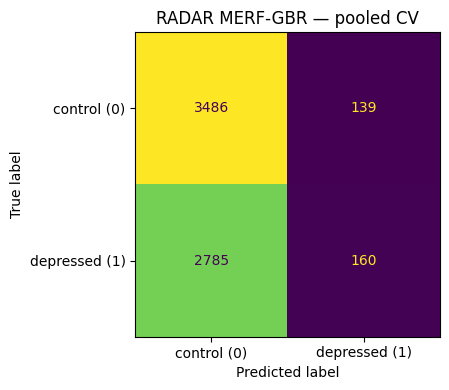

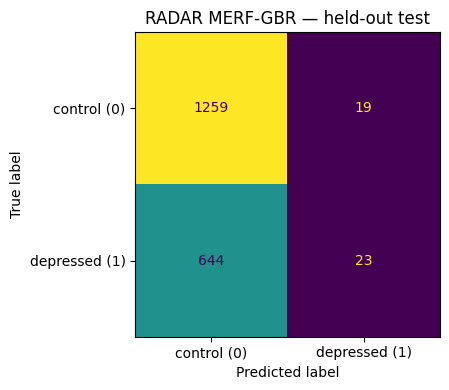


Pooled CV confusion matrix:
 [[3486  139]
 [2785  160]]

Held-out test confusion matrix:
 [[1259   19]
 [ 644   23]]

RADAR MERF-GBR SHAP summary (n=500):


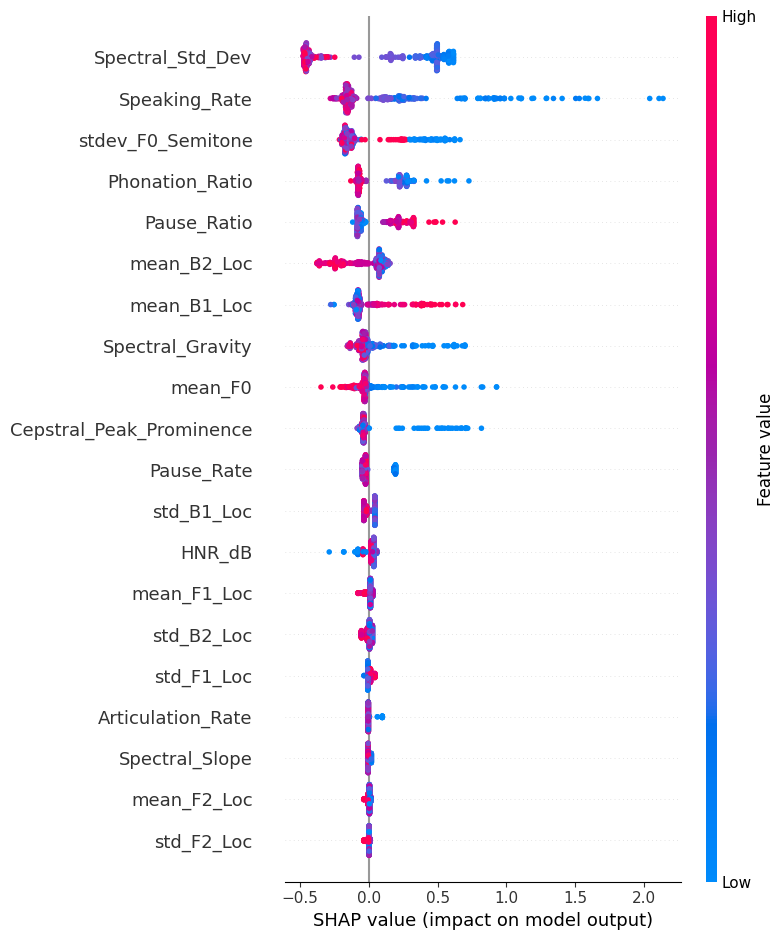


RADAR MERF-GBR LIME (2 instances):


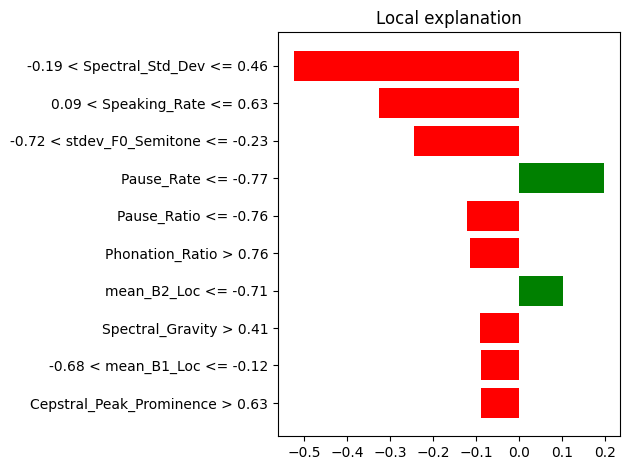

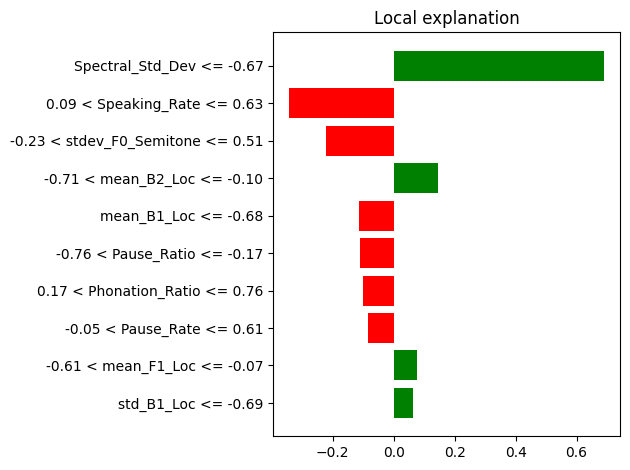


MODEL SECTION: Androids MERF-GBR



ValueError: could not convert string to float: 'N'

In [4]:
# MERF + GBR: install extras and run full evaluation pipeline
%pip install -q merf aif360 shap lime openpyxl

import importlib
import inspect
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "Models":
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks" / "Models"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import merf_gbr_pipeline
importlib.reload(merf_gbr_pipeline)  # pick up edits without kernel restart

from merf_gbr_pipeline import (
    run_all,
    EXCEL_EXPORT_PATH,
    CSV_EXPORT_DIR,
    GB_EXCEL_EXPORT_PATH,
)

# Sanity check: _fit_merf_predict must take 8 args (no y_va/y_test in the call)
_sig = inspect.signature(merf_gbr_pipeline._fit_merf_predict)
assert len(_sig.parameters) == 8, f"Stale module? _fit_merf_predict has {len(_sig.parameters)} params: {_sig}"
print(f"Loaded merf_gbr_pipeline from: {merf_gbr_pipeline.__file__}")

# Saves like Gradient Boosting copy:
#   results/logs/merf_gbr_results.xlsx
#   results/logs/merf_gbr/<sheet>.csv  (one CSV per sheet)
#   merges into results/logs/gradient_boosting_results.xlsx for figures_fainres.ipynb
run_all(export_excel=True, export_csv=True, merge_into_gb_workbook=True)
print(f"\nMERF Excel: {EXCEL_EXPORT_PATH}")
print(f"MERF CSVs:  {CSV_EXPORT_DIR}")
print(f"Combined (figures): {GB_EXCEL_EXPORT_PATH}")